In [72]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [73]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [74]:
data_df = pd.read_csv('/content/rice-type-classification/riceClassification.csv')
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [75]:
if 'id' in data_df.columns:
    data_df.drop(['id'], axis=1, inplace=True)
else:
    print("Column 'id' not found.")

data_df.dropna(inplace=True)
print(data_df.shape)

(18185, 11)


In [76]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [77]:
print(data_df['Class'].unique())

[1 0]


In [78]:
print(data_df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [79]:
original_df = data_df.copy()

for column in data_df.columns:
  data_df[column] = data_df[column] / data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [80]:
X = np.array(data_df.iloc[:,:-1])
Y = np.array(data_df.iloc[:,-1])

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(X , Y, test_size = 0.3)

In [82]:
X_test, X_val, Y_test, Y_val = train_test_split(X_test , Y_test, test_size = 0.5)

In [83]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [84]:
class dataset(Dataset):
  def __init__(self,X,Y):
     self.X=torch.tensor(X, dtype=torch.float32).to(device)
     self.Y=torch.tensor(Y, dtype=torch.float32).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.Y[index]


In [85]:
training_data = dataset(X_train,Y_train)
testing_data = dataset(X_test,Y_test)
validation_data = dataset(X_val,Y_val)

In [86]:
train_dataloader = DataLoader(training_data, batch_size=8, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=8, shuffle=True)

In [87]:
for x,y in train_dataloader:
  print(x)
  print('============================================')
  print(y)
  break

tensor([[0.5950, 0.7980, 0.6596, 0.9600, 0.5651, 0.7714, 0.5417, 0.6575, 0.7549,
         0.6864],
        [0.5686, 0.8849, 0.5563, 0.9920, 0.5385, 0.7540, 0.6020, 0.6816, 0.6712,
         0.9025],
        [0.4775, 0.7045, 0.5909, 0.9577, 0.4526, 0.6910, 0.6244, 0.5854, 0.7640,
         0.6764],
        [0.5526, 0.8371, 0.5798, 0.9827, 0.5295, 0.7434, 0.5029, 0.6585, 0.6989,
         0.8192],
        [0.6190, 0.8399, 0.6427, 0.9709, 0.5903, 0.7868, 0.6424, 0.6889, 0.7152,
         0.7414],
        [0.5343, 0.7909, 0.5918, 0.9738, 0.5125, 0.7309, 0.6122, 0.6326, 0.7322,
         0.7582],
        [0.7014, 0.9061, 0.6766, 0.9741, 0.6677, 0.8375, 0.6170, 0.7268, 0.7281,
         0.7597],
        [0.8275, 0.8425, 0.8541, 0.9201, 0.7816, 0.9097, 0.8091, 0.7270, 0.8585,
         0.5596]])
tensor([1., 1., 1., 1., 1., 1., 1., 0.])


In [88]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel,self).__init__()
    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
    self.linear = nn.Linear(HIDDEN_NEURONS,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x

model = MyModel().to(device)

In [89]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [90]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr =1e-3)

In [91]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 10
for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in train_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)
    batch_loss=criterion(prediction, labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()
    total_acc_train += acc

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():
    for data in validation_dataloader:
      inputs, labels = data
      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)
      total_loss_val += batch_loss.item()

      acc = ((prediction).round() == labels).sum().item()
      total_acc_val += acc
  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100 , 4))
  total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100, 4))
  print(f'''Epoch no. {epoch+1} Train loss : {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__() * 100 , 4)}
        Validation Loss : {round(total_loss_val/1000, 4)} Validation Accuracy{round(total_acc_val/validation_data.__len__() * 100, 4)}''')
  print("="*25)


Epoch no. 1 Train loss : 0.6205 Train Accuracy 92.8745
        Validation Loss : 0.0472 Validation Accuracy98.5337
Epoch no. 2 Train loss : 0.1413 Train Accuracy 98.4995
        Validation Loss : 0.022 Validation Accuracy98.6804
Epoch no. 3 Train loss : 0.0872 Train Accuracy 98.6173
        Validation Loss : 0.0173 Validation Accuracy98.5337
Epoch no. 4 Train loss : 0.0741 Train Accuracy 98.5623
        Validation Loss : 0.0157 Validation Accuracy98.5337
Epoch no. 5 Train loss : 0.0697 Train Accuracy 98.5545
        Validation Loss : 0.016 Validation Accuracy98.3871
Epoch no. 6 Train loss : 0.0685 Train Accuracy 98.5466
        Validation Loss : 0.0151 Validation Accuracy98.5337
Epoch no. 7 Train loss : 0.0678 Train Accuracy 98.5152
        Validation Loss : 0.0156 Validation Accuracy98.4604
Epoch no. 8 Train loss : 0.0664 Train Accuracy 98.5309
        Validation Loss : 0.015 Validation Accuracy98.607
Epoch no. 9 Train loss : 0.0668 Train Accuracy 98.5859
        Validation Loss : 0.0

In [92]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in test_dataloader:
    inputs, labels = data
    prediction = model(inputs).squeeze(1)

    batch_loss_test= criterion(prediction,labels).item()
    total_loss_test += batch_loss_test
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc

  print("Accuracy : ",round(total_acc_test/testing_data.__len__() * 100, 4))

Accuracy :  98.607


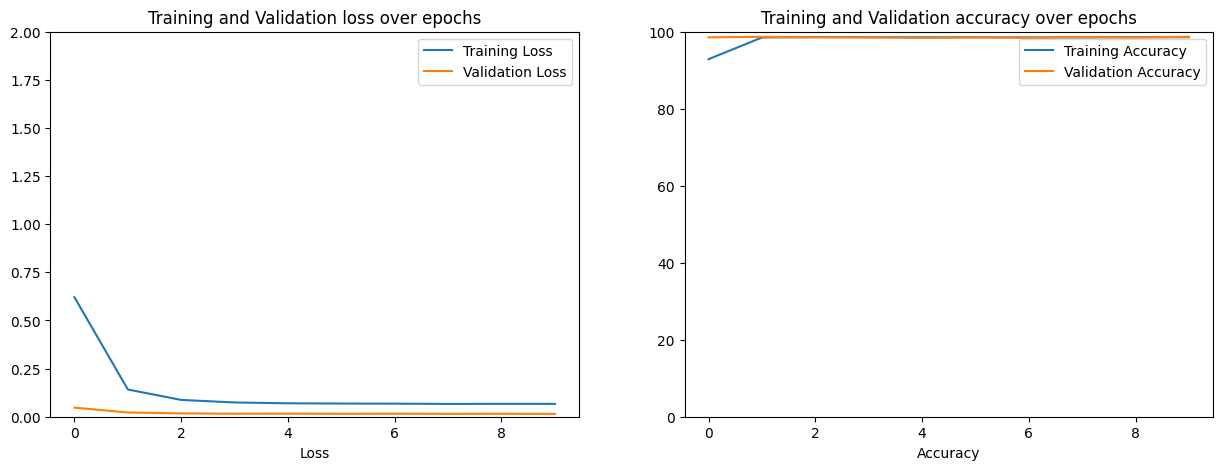

In [93]:
flg, axs = plt.subplots(nrows=1 , ncols=2, figsize= (15,5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title("Training and Validation loss over epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_xlabel('Loss')
axs[0].set_ylim([0,2])
axs[0].legend()


axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title("Training and Validation accuracy over epochs")
axs[1].set_xlabel('Epochs')
axs[1].set_xlabel('Accuracy')
axs[1].set_ylim([0,100])
axs[1].legend()

plt.show()

In [94]:
original_df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [95]:
original_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [99]:
Area = 2345/original_df['Area'].abs().max()

MajorAxisLength = 82/original_df['MajorAxisLength'].abs().max()

MinorAxisLength = 43/original_df['MinorAxisLength'].abs().max()

Eccentricity = 0.87/original_df['Eccentricity'].abs().max()

ConvexArea = 3222/original_df['ConvexArea'].abs().max()

EquivDiameter = 76/original_df['EquivDiameter'].abs().max()

Extent = 0.77/original_df['Extent'].abs().max()

Perimeter = 200/original_df['Perimeter'].abs().max()

Roundness = 0.43/original_df['Roundness'].abs().max()

AspectRation = 1.1/original_df['AspectRation'].abs().max()

my_prediction = model(torch.tensor([Area, MajorAxisLength, MinorAxisLength, Eccentricity,
       ConvexArea, EquivDiameter,Extent,Perimeter, Roundness,
       AspectRation], dtype=torch.float32).to(device))


In [100]:
round(my_prediction.item())

1